<a href="https://colab.research.google.com/github/rajak-abh/algo-lab/blob/main/Lab_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 2. Divide and Conquer (Sorting)

- **Created by Dr. Ajay

Write a python program to perform **Countingsort**.
* Statement:  Given a disordered list of repeated integers, rearrange the integers in natural order.
 Sample Input: [4,3,2,1,4,3,2,4,3,4]
 Sample Output: [1,2,2,3,3,3,4,4,4,4]

Time Complexity of Solution: Best Case O(n+k); Average Case O(n+k); Worst Case O(n+k), where n is the size of the input array and k means the values range from 0 to k.
- Approach:
Counting sort, like radix sort and bucket sort, is an integer based algorithm (i.e. the values of the input array are assumed to be integers). Hence counting sort is among the fastest sorting algorithms around, in theory. The  particular distinction for counting sort is that it creates a bucket for each value and keep a counter in each bucket. Then each time a value is encountered in the input collection, the appropriate counter is incremented. Because counting sort creates a bucket for each value, an imposing restriction is that the maximum value in the input array be known beforehand. Bucket sort uses a hash function to distribute values; counting sort, on the other hand, creates a counter for each value -- hence the name.
- Implementation notes:
1. Since the values range from 0 to k, create k+1 buckets.

2. To fill the buckets, iterate through the input list and
each time a value appears, increment the counter in its bucket.
3. Now fill the input list with the compressed data in the
buckets. Each bucket's key represents a value in the  array. So for each bucket, from smallest key to largest, add the index of the bucket to the input array and decrease the counter in said bucket by one; until the counter is zero.

Size: 5000, Time: 0.00140s
Size: 10000, Time: 0.00269s
Size: 20000, Time: 0.00575s
Size: 40000, Time: 0.01151s
Size: 80000, Time: 0.02487s
Size: 160000, Time: 0.05057s


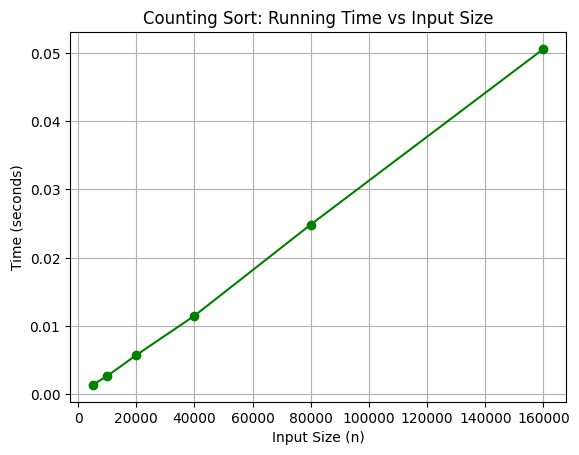

In [3]:
#write code for above cell and compute the running time and also plot graph.
import time
import random
import matplotlib.pyplot as plt

# 1. Counting Sort Algorithm
def counting_sort(arr):
    if not arr:
        return arr
    max_val = max(arr)
    min_val = min(arr)
    range_of_elements = max_val - min_val + 1
    count = [0] * range_of_elements
    output = [0] * len(arr)

    for num in arr:
        count[num - min_val] += 1

    for i in range(1, len(count)):
        count[i] += count[i - 1]

    for i in range(len(arr) - 1, -1, -1):
        output[count[arr[i] - min_val] - 1] = arr[i]
        count[arr[i] - min_val] -= 1
    return output

# 2. Code to Compute Running Time
sizes = [5000, 10000, 20000, 40000, 80000, 160000]
times = []
k = 1000  # Fixed range for the numbers

for n in sizes:
    test_arr = [random.randint(0, k) for _ in range(n)]
    start_time = time.time()
    counting_sort(test_arr)
    end_time = time.time()
    times.append(end_time - start_time)
    print(f"Size: {n}, Time: {end_time - start_time:.5f}s")

# 3. Code to Plot the Graph
plt.plot(sizes, times, marker='o', linestyle='-', color='g')
plt.title('Counting Sort: Running Time vs Input Size')
plt.xlabel('Input Size (n)')
plt.ylabel('Time (seconds)')
plt.grid(True)
plt.savefig('counting_sort_plot.png')

 - *Bucketsort*
Statement:
Given a disordered list of integers, rearrange them in natural order.
 Sample Input: [8,5,3,1,9,6,0,7,4,2,5]
 Sample Output: [0,1,2,3,4,5,6,7,8,9,5]
Time Complexity of Solution:
Best Case O(n); Average Case O(n); Worst Case O(n).
- Approach:
If it sounds too good to be true, then most likely it's not true. Bucketsort is not an exception to this adage. For bucketsort to
work at its blazing efficiency, there are multiple prerequisites.
First the hash function that is used to partition the elements need
to be very good and must produce ordered hash: if i < k then
hash(i) < hash(k). Second, the elements to be sorted must be
uniformly distributed.
  The aforementioned aside, bucket sort is actually very good
considering that counting sort is reasonably speaking its upper
bound. And counting sort is very fast. The particular distinction
for bucket sort is that it uses a hash function to partition the
keys of the input array, so that multiple keys may hash to the same
bucket. Hence each bucket must effectively be a growable list;
similar to radix sort.


Size: 1000, Time: 0.00050s
Size: 5000, Time: 0.00456s
Size: 10000, Time: 0.00588s
Size: 15000, Time: 0.00922s
Size: 20000, Time: 0.01472s
Size: 25000, Time: 0.01884s
Size: 30000, Time: 0.08912s


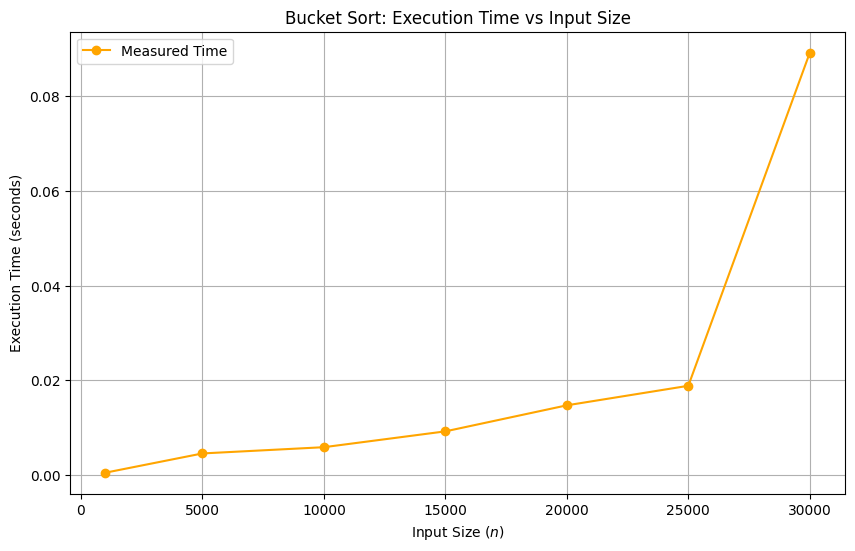

In [4]:
#write code for above cell and compute the running time and also plot graph.
import time
import random
import matplotlib.pyplot as plt

def bucket_sort(arr):
    if not arr:
        return arr

    num_buckets = len(arr)
    buckets = [[] for _ in range(num_buckets)]

    max_val, min_val = max(arr), min(arr)
    if max_val == min_val: return arr
    range_val = max_val - min_val

    # Distribute elements into buckets
    for x in arr:
        index = int((x - min_val) / range_val * (num_buckets - 1))
        buckets[index].append(x)

    # Sort each bucket and concatenate
    k = 0
    for bucket in buckets:
        bucket.sort()
        for x in bucket:
            arr[k] = x
            k += 1
    return arr

# --- Performance Measurement ---
sizes = [1000, 5000, 10000, 15000, 20000, 25000, 30000]
execution_times = []

for n in sizes:
    test_data = [random.uniform(0, 1000) for _ in range(n)]

    start_time = time.time()
    bucket_sort(test_data)
    end_time = time.time()

    execution_times.append(end_time - start_time)
    print(f"Size: {n}, Time: {end_time - start_time:.5f}s")

# --- Graph Generation ---
plt.figure(figsize=(10, 6))
plt.plot(sizes, execution_times, marker='o', linestyle='-', color='orange', label='Measured Time')
plt.title('Bucket Sort: Execution Time vs Input Size')
plt.xlabel('Input Size ($n$)')
plt.ylabel('Execution Time (seconds)')
plt.legend()
plt.grid(True)
plt.savefig('bucket_sort_analysis.png')

**Radix sort**
Statement:Given a disordered list of integers, rearrange them in natural order.
Sample Input: [18,5,100,3,1,19,6,0,7,4,2]
Sample Output: [0,1,2,3,4,5,6,7,18,19,100]
Time Complexity of Solution:Best Case O(kn); Average Case O(kn); Worst Case O(kn),where k is the length of the longest number and n is the size of the input array.Note: if k is greater than log(n) then an nlog(n) algorithm would be a better fit. In reality we can always change the radix to make k less than log(n).
- Approach: radix sort, like counting sort and bucket sort, is an integer based algorithm (i.e. the values of the input array are assumed to be integers). Hence radix sort is among the fastest sorting algorithms around, in theory. The particular distinction for radix sort is that it creates a bucket for each cipher (i.e. digit); as such, similar to bucket sort, each bucket in radix sort must be a
growable list that may admit different keys. For decimal values, the number of buckets is 10, as the decimal system has 10 numerals/cyphers (i.e. 0,1,2,3,4,5,6,7,8,9). Then the keys are continuously sorted by significant digits.

Original Sample Input: [18, 5, 100, 3, 1, 19, 6, 0, 7, 4, 2]
Sorted Sample Output: [0, 1, 2, 3, 4, 5, 6, 7, 18, 19, 100]
Expected Output: [0, 1, 2, 3, 4, 5, 6, 7, 18, 19, 100]
Match Expected Output: True

Measuring running time for Radix Sort...
List size (n): 1000, Time taken: 0.002354s
List size (n): 5000, Time taken: 0.012505s
List size (n): 10000, Time taken: 0.024475s
List size (n): 20000, Time taken: 0.069602s
List size (n): 50000, Time taken: 0.207979s
List size (n): 100000, Time taken: 0.452748s
List size (n): 200000, Time taken: 0.950236s


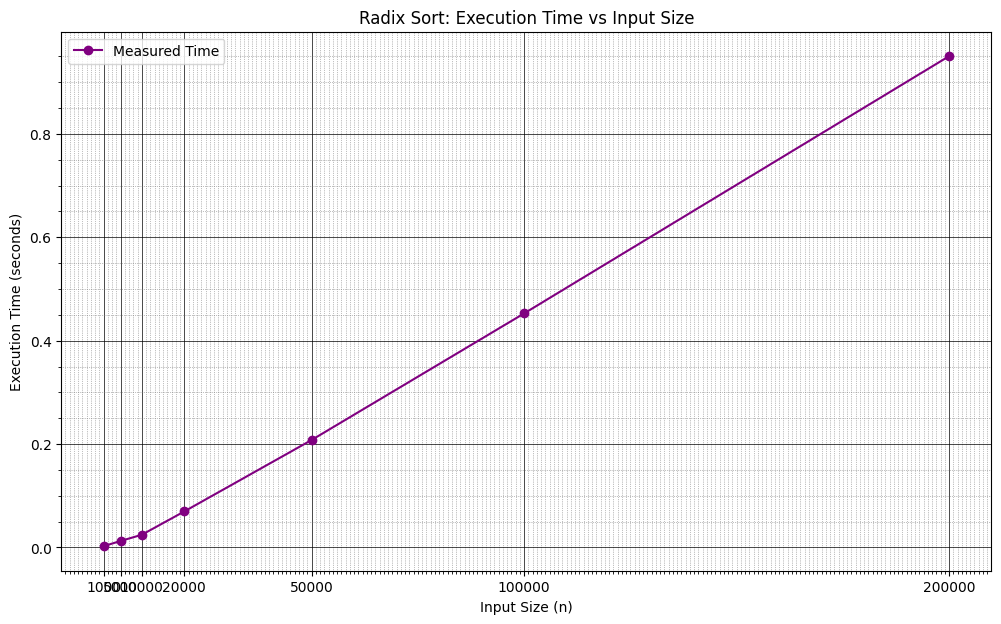


Note: The theoretical time complexity of Radix Sort is O(kn), where n is the size of the input array and k is the number of digits in the maximum number.
In this experiment, 'k' is determined by max_number_range (10000), which implies numbers with up to 5 digits.


In [11]:
#write code for above cell and compute the running time and also plot graph.
import time
import random
import matplotlib.pyplot as plt

def counting_sort_for_radix(arr, exp):
    n = len(arr)
    output = [0] * n
    count = [0] * 10  # For base 10 digits (0-9)

    # Store count of occurrences in count[]
    for i in range(n):
        index = (arr[i] // exp) % 10
        count[index] += 1

    # Change count[i] so that count[i] now contains actual
    # position of this digit in output array
    for i in range(1, 10):
        count[i] += count[i - 1]

    # Build the output array
    i = n - 1
    while i >= 0:
        index = (arr[i] // exp) % 10
        output[count[index] - 1] = arr[i]
        count[index] -= 1
        i -= 1

    # Copying the output array to arr[], so that arr[] now
    # contains sorted numbers according to current digit
    for i in range(n):
        arr[i] = output[i]

def radix_sort(arr):
    if not arr:
        return arr

    # Find the maximum number to know number of digits
    max_val = max(arr)

    # Do counting sort for every digit. Note that instead
    # of passing digit number, exp is passed. exp is 10^i
    # where i is current digit number
    exp = 1
    while max_val // exp > 0:
        counting_sort_for_radix(arr, exp)
        exp *= 10
    return arr

# --- Testing the algorithm with the sample input ---
sample_input = [18, 5, 100, 3, 1, 19, 6, 0, 7, 4, 2]
print(f"Original Sample Input: {sample_input}")
sorted_sample_input = radix_sort(list(sample_input)) # Pass a copy
print(f"Sorted Sample Output: {sorted_sample_input}")
expected_output = [0, 1, 2, 3, 4, 5, 6, 7, 18, 19, 100]
print(f"Expected Output: {expected_output}")
print(f"Match Expected Output: {sorted_sample_input == expected_output}")

# --- Computing running time and plotting graph ---
sizes = [1000, 5000, 10000, 20000, 50000, 100000, 200000]
execution_times = []

# Max value to ensure numbers have varying digits, affecting 'k' in O(kn)
max_number_range = 10000 # Numbers will be between 0 and 9999 (up to 4 digits)

print("\nMeasuring running time for Radix Sort...")
for n in sizes:
    # Generate a list of random non-negative integers
    test_data = [random.randint(0, max_number_range) for _ in range(n)]

    start_time = time.time()
    radix_sort(test_data)
    end_time = time.time()

    elapsed_time = end_time - start_time
    execution_times.append(elapsed_time)
    print(f"List size (n): {n}, Time taken: {elapsed_time:.6f}s")

# --- Graph Generation ---
plt.figure(figsize=(12, 7))
plt.plot(sizes, execution_times, marker='o', linestyle='-', color='purple', label='Measured Time')
plt.title('Radix Sort: Execution Time vs Input Size')
plt.xlabel('Input Size (n)')
plt.ylabel('Execution Time (seconds)')
plt.legend()
plt.grid(True)
plt.xticks(sizes)
plt.minorticks_on()
plt.grid(which='major', linestyle='-', linewidth='0.5', color='black')
plt.grid(which='minor', linestyle=':', linewidth='0.5', color='gray')
plt.show()

print("\nNote: The theoretical time complexity of Radix Sort is O(kn), where n is the size of the input array and k is the number of digits in the maximum number.")
print(f"In this experiment, 'k' is determined by max_number_range ({max_number_range}), which implies numbers with up to {len(str(max_number_range))} digits.")